In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("results.csv", header=None, on_bad_lines='skip', names=["secret", "result", "q-value"] + list(range(1100)))
df.head()

,secret,result,q-value,0,1,2,3,4,5,6,...,1090,1091,1092,1093,1094,1095,1096,1097,1098,1099
0,293386888,Correct,0.05,4214784,4214788,4214789,4214792,4214796,4214800,4214803,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,121821982,Correct,0.10,4214784,4214788,4214789,4214792,4214796,4214803,4214807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,535693153,Correct,0.15,4214784,4214788,4214789,4214800,4214803,4214807,4214814,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,976803969,Correct,0.20,4214784,4214788,4214789,4214796,4214800,4214807,4214814,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,724457988,Correct,0.25,4214784,4214789,4214792,4214800,4214803,4214814,4214822,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49681 entries, 0 to 49680
Columns: 1103 entries, secret to 1099
dtypes: float64(1068), int64(34), object(1)
memory usage: 418.1+ MB


In [4]:
# Get only the relevant metadata
df_metadata = df[["secret", "result", "q-value"]]
df_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49681 entries, 0 to 49680
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   secret   49681 non-null  int64  
 1   result   49681 non-null  object 
 2   q-value  49681 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


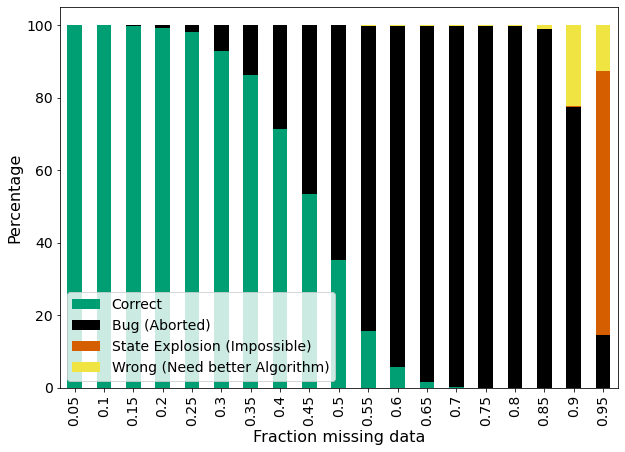

In [5]:
# group by result and q-value, and count the occurrences of each result
result_counts = df_metadata.groupby(['result', 'q-value']).size().reset_index(name='count')

# calculate the total count for each q-value group
total_counts = result_counts.groupby('q-value')['count'].transform('sum')

# divide the count for each result by the total count to get the percentage
result_counts['percentage'] = result_counts['count'] / total_counts * 100

# pivot the dataframe so that each result is a separate column
result_pivot = result_counts.pivot(index='q-value', columns='result', values='percentage')

# plot the stacked bar chart


# set axis labels and title
cmap ={
    "Bluish green": (0, 158, 115),
    "Black": (0, 0, 0),
    "Yellow" : (240, 228, 66),
    "Orange" : (230, 159, 0),
    "Vermillion": (213, 94, 0)
}

for c,v in cmap.items():
    cmap[c] = tuple(x/255 for x in v)
colors = {' Correct': cmap["Bluish green"], ' No solution found': cmap["Black"],  ' Wrong': cmap['Yellow'], ' Too many states': cmap['Vermillion']}

with plt.style.context('./arend.mplstyle'):
    ax = result_pivot.plot(kind='bar', stacked=True, color = colors)
    plt.xlabel('Fraction missing data')
    plt.ylabel('Percentage')
    labels = ["Correct", "Bug (Aborted)", "State Explosion (Impossible)", "Wrong (Need better Algorithm)"]
    plt.legend(labels, fontsize=14)

    plt.savefig("square_mult_missing.pdf")
    plt.savefig("square_mult_missing.png")
    plt.savefig("square_mult_missing.eps")
    plt.show()

In [6]:
df_metadata.groupby(['q-value']).size().reset_index(name='count')['count']

0     2313
1     2644
2     2622
3     2653
4     2634
5     2632
6     2630
7     2637
8     2647
9     2643
10    2610
11    2626
12    2634
13    2630
14    2636
15    2620
16    2634
17    2609
18    2627
Name: count, dtype: int64

In [7]:
result_pivot

result,Correct,No solution found,Too many states,Wrong
q-value,,,,
0.05,100.000000,NaN,NaN,NaN
0.10,99.962179,0.037821,NaN,NaN
0.15,99.885584,0.114416,NaN,NaN
0.20,99.359216,0.640784,NaN,NaN
0.25,98.101746,1.898254,NaN,NaN
0.30,92.819149,7.180851,NaN,NaN
0.35,86.273764,13.726236,NaN,NaN
0.40,71.255214,28.744786,NaN,NaN
0.45,53.305629,46.694371,NaN,NaN
